In [147]:
pip install pandas numpy scikit-learn

Import Packages

In [148]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

Load data set

In [149]:
import pandas as pd

train = pd.read_csv("case1Data.csv")
test = pd.read_csv("case1Data_Xnew.csv")

In [150]:
train.head(10)

,y,x_01,x_02,x_03,x_04,x_05,x_06,x_07,x_08,x_09,...,x_91,x_92,x_93,x_94,x_95,C_01,C_02,C_03,C_04,C_05
0,375.823073,6.359019,-13.367120,-2.483750,-6.641891,11.733539,NaN,-17.085361,22.194764,16.827888,...,-10.200888,3.980048,-4.433274,-1.473723,NaN,74.0,72.0,72.0,73.0,73.0
1,266.811730,3.873664,-8.470389,-3.055012,NaN,11.420983,1.822330,-13.694100,22.738654,20.307503,...,-9.740207,NaN,-2.629314,4.816987,-12.240248,74.0,72.0,72.0,73.0,73.0
2,267.271759,5.275824,-12.070531,-1.366168,-4.819100,10.721527,-5.125992,-17.476865,NaN,15.963889,...,-14.501970,10.054005,NaN,NaN,-11.107921,73.0,72.0,75.0,74.0,74.0
3,219.951294,4.430110,-4.467975,-0.730736,-10.047104,11.498539,-2.870260,-14.033012,18.225190,10.409488,...,-11.086963,2.019726,-8.531959,3.520833,NaN,71.0,72.0,73.0,71.0,72.0
4,289.697954,3.116458,-8.518713,-6.796050,NaN,7.646285,-3.118309,-13.102567,22.801217,16.680208,...,-9.117422,6.627601,-2.805531,5.914351,-11.240573,72.0,72.0,72.0,74.0,75.0
5,265.753204,2.478883,-10.347278,-3.574333,-4.320143,NaN,-3.326662,-13.197508,23.424267,12.551075,...,-11.571283,7.487204,-5.098366,3.175914,-9.610356,71.0,72.0,74.0,71.0,75.0
6,133.594186,0.497803,-9.389992,-7.230404,-8.852222,12.308068,-5.288380,-9.998207,23.229430,13.491712,...,-15.720359,NaN,-6.235942,4.124001,-16.268568,74.0,72.0,75.0,71.0,75.0
7,252.251096,7.627311,-7.146660,0.244472,0.182987,NaN,-0.395215,-14.423119,NaN,NaN,...,-10.710254,7.884195,-2.402023,NaN,-4.631043,74.0,72.0,73.0,75.0,73.0
8,163.402815,4.981034,-8.719028,-5.484942,-5.919929,9.916674,-4.726807,-10.606375,24.903043,12.151393,...,-11.139651,7.096430,-2.865486,7.464922,-8.441735,NaN,NaN,NaN,NaN,NaN
9,282.511836,0.519655,-14.477831,-2.121282,NaN,12.080162,-6.393721,-11.599432,NaN,11.984299,...,-14.195198,2.409425,-3.523658,2.821658,-14.591262,75.0,72.0,72.0,74.0,71.0


Check data set size

In [151]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (100, 101)
Test shape: (1000, 100)


In [152]:
print(train.columns)

Index(['y', 'x_01', 'x_02', 'x_03', 'x_04', 'x_05', 'x_06', 'x_07', 'x_08',
       'x_09',
       ...
       'x_91', 'x_92', 'x_93', 'x_94', 'x_95', 'C_01', 'C_02', 'C_03', 'C_04',
       'C_05'],
      dtype='object', length=101)


In [153]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Columns: 101 entries, y to C_05
dtypes: float64(101)
memory usage: 79.0 KB


Check duplicates

In [154]:
X = train.drop(columns=["y"])
y = train["y"]

In [155]:
print("Full duplicates:", train.duplicated().sum())
print("Feature duplicates:", X.duplicated().sum())

Full duplicates: 0
Feature duplicates: 0


Check outliers using y distribution

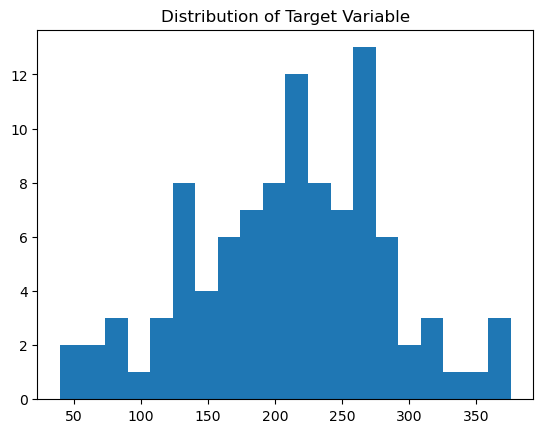

In [156]:
import matplotlib.pyplot as plt

plt.hist(y, bins=20)
plt.title("Distribution of Target Variable")
plt.savefig("Histogram trainset.png")
plt.show()

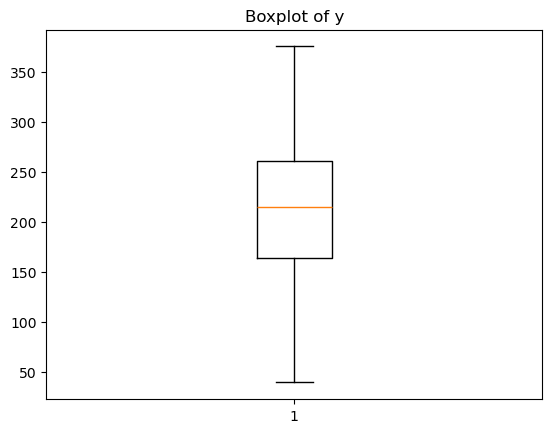

In [157]:
plt.boxplot(y)
plt.title("Boxplot of y")
plt.savefig("Boxplot.png")
plt.show()

In [158]:
y.describe()

count    100.000000
mean     211.521238
std       72.476499
min       39.702218
25%      163.757582
50%      215.257947
75%      260.907758
max      375.823073
Name: y, dtype: float64

Get missing value percentage for each variable

In [159]:
train.isna().sum().sort_values(ascending=False).head(10)

x_85    27
x_12    24
C_01    22
x_65    22
C_02    22
C_03    22
C_05    22
C_04    22
x_20    21
x_02    21
dtype: int64

Define x and y

Missing value visualization

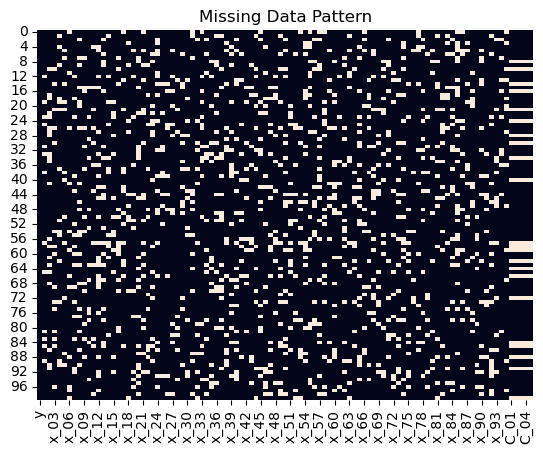

In [160]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(train.isnull(), cbar=False)
plt.title("Missing Data Pattern")
plt.savefig("Missing value distribution.png")
plt.show()

Check C01 to C05

In [161]:
for col in ["C_01", "C_02", "C_03", "C_04", "C_05"]:
    print(col, train[col].nunique())

C_01 5
C_02 1
C_03 5
C_04 5
C_05 5


Check further about C02

In [162]:
train["C_02"].value_counts()


C_02
72.0    78
Name: count, dtype: int64

In [163]:
train["C_02"].var()

0.0

In [164]:
constant_cols = train.columns[train.nunique() == 1]
print(constant_cols)

Index(['C_02'], dtype='object')


Drop C_02

In [165]:
train = train.drop(columns=["C_02"])
test = test.drop(columns=["C_02"])

Recreate

In [166]:
X = train.drop(columns=["y"])
y = train["y"]

Split Columns

In [167]:
num_cols = [col for col in X.columns if col.startswith("x_")]
cat_cols = [col for col in X.columns if col.startswith("C_")]

Compute skewness

In [168]:
skewness = X[num_cols].skew()

In [169]:
symmetric = skewness[abs(skewness) < 0.5].index
moderate = skewness[(abs(skewness) >= 0.5) & (abs(skewness) < 1)].index
highly_skewed = skewness[abs(skewness) >= 1].index

print("Symmetric:", len(symmetric))
print("Moderately skewed:", len(moderate))
print("Highly skewed:", len(highly_skewed))

Symmetric: 90
Moderately skewed: 5
Highly skewed: 0


Decided to replace missing value by mean:Skewness analysis showed that 90% of the features were approximately symmetric, while only a small number exhibited moderate skewness. Since no variables were highly skewed, mean imputation was applied consistently across all numerical features to ensure stability and simplicity in a high-dimensional setting.

## Preprocessing

In [170]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

## K-fold CV

Ridge-Kfold

In [171]:
from sklearn.linear_model import Ridge

cv = KFold(n_splits=10, shuffle=True, random_state=42)

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
ridge_results = {}

for alpha in alphas:
    rmse_folds = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = Pipeline([
            ("preprocess", preprocessor),
            ("model", Ridge(alpha=alpha))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, y_pred))
        rmse_folds.append(rmse)

    ridge_results[alpha] = np.mean(rmse_folds)

best_alpha_kfold = min(ridge_results, key=ridge_results.get)
rmse_ridge = ridge_results[best_alpha_kfold]

print("K-Fold Best alpha:", best_alpha_kfold)
print("K-Fold RMSE:", rmse_ridge)

K-Fold Best alpha: 5
K-Fold RMSE: 30.01191021832998


Lasso-Kfold

In [172]:
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
lasso_results = {}

for alpha in alphas:
    rmse_folds = []

    for train_idx, val_idx in cv.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = Pipeline([
            ("preprocess", preprocessor),
            ("model", Lasso(alpha=alpha, max_iter=50000))
        ])

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    lasso_results[alpha] = np.mean(rmse_folds)

best_alpha_kfold_lasso = min(lasso_results, key=lasso_results.get)
rmse_lasso = lasso_results[best_alpha_kfold_lasso]

print("K-Fold Best alpha:", best_alpha_kfold_lasso)
print("K-Fold RMSE:", rmse_lasso)

K-Fold Best alpha: 0.5
K-Fold RMSE: 30.277762838032594


Elastic Net-K fold

In [173]:
from sklearn.linear_model import ElasticNet

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
enet_results = {}

for alpha in alphas:
    for l1 in [0.2, 0.5, 0.8]:
        rmse_folds = []

        for train_idx, val_idx in cv.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = Pipeline([
                ("preprocess", preprocessor),
                ("model", ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000))
            ])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))

        enet_results[(alpha, l1)] = np.mean(rmse_folds)

best_alpha_kfold_enet = min(enet_results, key=enet_results.get)
rmse_enet = enet_results[best_alpha_kfold_enet]

print("K-Fold Best alpha:", best_alpha_kfold_enet)
print("K-Fold RMSE:", rmse_enet)

K-Fold Best alpha: (0.1, 0.8)
K-Fold RMSE: 29.713095638103237


Random forest- kfold

In [174]:
from sklearn.ensemble import RandomForestRegressor

rf_results = {}

for n in [100, 200]:
    for depth in [None, 5, 10]:
        rmse_folds = []

        for train_idx, val_idx in cv.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = Pipeline([
                ("preprocess", preprocessor),
                ("model", RandomForestRegressor(
                    n_estimators=n,
                    max_depth=depth,
                    random_state=42
                ))
            ])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))

        rf_results[(n, depth)] = np.mean(rmse_folds)

rmse_rf = min(rf_results, key=rf_results.get)
print("Best RF params:", rmse_rf)
print("Best RF RMSE:", rf_results[rmse_rf])

Best RF params: (200, 10)
Best RF RMSE: 43.85328421569763


Gradient Boost-Kfold

In [175]:
from sklearn.ensemble import GradientBoostingRegressor

gb_results = {}

for lr in [0.01, 0.1]:
    for n in [100, 200]:
        rmse_folds = []

        for train_idx, val_idx in cv.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = Pipeline([
                ("preprocess", preprocessor),
                ("model", GradientBoostingRegressor(
                    learning_rate=lr,
                    n_estimators=n,
                    random_state=42
                ))
            ])

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)

            rmse_folds.append(np.sqrt(mean_squared_error(y_val, y_pred)))

        gb_results[(lr, n)] = np.mean(rmse_folds)

rmse_gbr = min(gb_results, key=gb_results.get)
print("Best GBR params:", rmse_gbr)
print("Best GBR RMSE:", gb_results[rmse_gbr])

Best GBR params: (0.1, 200)
Best GBR RMSE: 40.56534447287491


## Nested CV

Ridge

In [176]:
from sklearn.linear_model import Ridge

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
outer_rmse_ridge = []
chosen_alphas = []

for train_idx, test_idx in outer_cv.split(X):

    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

    inner_results = {}

    for alpha in alphas:
        rmse_inner = []

        for train_i, val_i in inner_cv.split(X_train_outer):

            X_train_inner = X_train_outer.iloc[train_i]
            X_val_inner = X_train_outer.iloc[val_i]
            y_train_inner = y_train_outer.iloc[train_i]
            y_val_inner = y_train_outer.iloc[val_i]

            model = Pipeline([
                ("preprocess", preprocessor),
                ("model", Ridge(alpha=alpha))
            ])

            model.fit(X_train_inner, y_train_inner)
            y_pred = model.predict(X_val_inner)

            rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred)))

        inner_results[alpha] = np.mean(rmse_inner)

    best_alpha = min(inner_results, key=inner_results.get)
    chosen_alphas.append(best_alpha)

    final_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", Ridge(alpha=best_alpha))
    ])

    final_model.fit(X_train_outer, y_train_outer)
    y_pred = final_model.predict(X_test_outer)

    outer_rmse_ridge.append(np.sqrt(mean_squared_error(y_test_outer, y_pred)))

print("Nested CV RMSE (mean):", np.mean(outer_rmse_ridge))
print("Nested CV RMSE (std):", np.std(outer_rmse_ridge))
print("Chosen alphas per fold:", chosen_alphas)

Nested CV RMSE (mean): 31.185990533436684
Nested CV RMSE (std): 6.245435336553294
Chosen alphas per fold: [5, 5, 1, 5, 5, 1, 5, 5, 5, 5]


Lasso

In [177]:
from sklearn.linear_model import Lasso

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
outer_rmse_lasso = []
chosen_alphas = []

for train_idx, test_idx in outer_cv.split(X):

    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

    inner_results = {}

    for alpha in alphas:
        rmse_inner = []

        for train_i, val_i in inner_cv.split(X_train_outer):

            X_train_inner = X_train_outer.iloc[train_i]
            X_val_inner = X_train_outer.iloc[val_i]
            y_train_inner = y_train_outer.iloc[train_i]
            y_val_inner = y_train_outer.iloc[val_i]

            model = Pipeline([
                ("preprocess", preprocessor),
                ("model", Lasso(alpha=alpha, max_iter=50000))
            ])

            model.fit(X_train_inner, y_train_inner)
            y_pred = model.predict(X_val_inner)

            rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred)))

        inner_results[alpha] = np.mean(rmse_inner)

    best_alpha = min(inner_results, key=inner_results.get)
    chosen_alphas.append(best_alpha)

    final_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", Lasso(alpha=best_alpha, max_iter=50000))
    ])

    final_model.fit(X_train_outer, y_train_outer)
    y_pred = final_model.predict(X_test_outer)

    outer_rmse_lasso.append(np.sqrt(mean_squared_error(y_test_outer, y_pred)))

print("Nested CV RMSE (mean):", np.mean(outer_rmse_lasso))
print("Nested CV RMSE (std):", np.std(outer_rmse_lasso))
print("Chosen alphas per fold:", chosen_alphas)

Nested CV RMSE (mean): 31.78013208074095
Nested CV RMSE (std): 4.628800510834456
Chosen alphas per fold: [0.5, 0.5, 0.5, 5, 5, 0.5, 0.5, 0.5, 1, 1]


Elastic-Net

In [178]:
from sklearn.linear_model import ElasticNet

alphas = [0.01, 0.1, 0.5, 1, 5, 10]
l1_ratios = [0.2, 0.5, 0.8]

outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

outer_rmse_enet = []
chosen_params_enet = []

for train_idx, test_idx in outer_cv.split(X):

    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

    inner_results = {}

    for alpha in alphas:
        for l1 in l1_ratios:

            rmse_inner = []

            for train_i, val_i in inner_cv.split(X_train_outer):

                X_train_inner = X_train_outer.iloc[train_i]
                X_val_inner = X_train_outer.iloc[val_i]
                y_train_inner = y_train_outer.iloc[train_i]
                y_val_inner = y_train_outer.iloc[val_i]

                model = Pipeline([
                    ("preprocess", preprocessor),
                    ("model", ElasticNet(alpha=alpha, l1_ratio=l1, max_iter=10000))
                ])

                model.fit(X_train_inner, y_train_inner)
                y_pred = model.predict(X_val_inner)

                rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred)))

            inner_results[(alpha, l1)] = np.mean(rmse_inner)

    best_params = min(inner_results, key=inner_results.get)
    chosen_params_enet.append(best_params)

    final_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", ElasticNet(alpha=best_params[0], l1_ratio=best_params[1], max_iter=10000))
    ])

    final_model.fit(X_train_outer, y_train_outer)
    y_pred = final_model.predict(X_test_outer)

    outer_rmse_enet.append(np.sqrt(mean_squared_error(y_test_outer, y_pred)))

print("Elastic Net Nested RMSE (mean):", np.mean(outer_rmse_enet))
print("Elastic Net Nested RMSE (std):", np.std(outer_rmse_enet))
print("Chosen params:", chosen_params_enet)

Elastic Net Nested RMSE (mean): 30.368992532949626
Elastic Net Nested RMSE (std): 7.425123711071554
Chosen params: [(0.5, 0.8), (0.1, 0.8), (0.1, 0.8), (0.1, 0.5), (0.1, 0.8), (0.1, 0.8), (0.1, 0.8), (0.1, 0.8), (0.1, 0.8), (0.5, 0.8)]


Random Forest

In [179]:
from sklearn.ensemble import RandomForestRegressor

n_estimators_list = [100, 200]
max_depths = [None, 5, 10]

outer_rmse_rf = []
chosen_params_rf = []

for train_idx, test_idx in outer_cv.split(X):

    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

    inner_results = {}

    for n in n_estimators_list:
        for depth in max_depths:

            rmse_inner = []

            for train_i, val_i in inner_cv.split(X_train_outer):

                X_train_inner = X_train_outer.iloc[train_i]
                X_val_inner = X_train_outer.iloc[val_i]
                y_train_inner = y_train_outer.iloc[train_i]
                y_val_inner = y_train_outer.iloc[val_i]

                model = Pipeline([
                    ("preprocess", preprocessor),
                    ("model", RandomForestRegressor(
                        n_estimators=n,
                        max_depth=depth,
                        random_state=42
                    ))
                ])

                model.fit(X_train_inner, y_train_inner)
                y_pred = model.predict(X_val_inner)

                rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred)))

            inner_results[(n, depth)] = np.mean(rmse_inner)

    best_params = min(inner_results, key=inner_results.get)
    chosen_params_rf.append(best_params)

    final_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=best_params[0],
            max_depth=best_params[1],
            random_state=42
        ))
    ])

    final_model.fit(X_train_outer, y_train_outer)
    y_pred = final_model.predict(X_test_outer)

    outer_rmse_rf.append(np.sqrt(mean_squared_error(y_test_outer, y_pred)))

print("Random Forest Nested RMSE (mean):", np.mean(outer_rmse_rf))
print("Random Forest Nested RMSE (std):", np.std(outer_rmse_rf))
print("Chosen params:", chosen_params_rf)

Random Forest Nested RMSE (mean): 44.200249906822236
Random Forest Nested RMSE (std): 11.501438517922915
Chosen params: [(100, 5), (100, 5), (100, 10), (200, 10), (100, 5), (200, None), (100, None), (100, 5), (200, 5), (200, 5)]


Gradient Boost

In [180]:
from sklearn.ensemble import GradientBoostingRegressor

learning_rates = [0.01, 0.1]
n_estimators_list = [100, 200]

outer_rmse_gb = []
chosen_params_gb = []

for train_idx, test_idx in outer_cv.split(X):

    X_train_outer, X_test_outer = X.iloc[train_idx], X.iloc[test_idx]
    y_train_outer, y_test_outer = y.iloc[train_idx], y.iloc[test_idx]

    inner_results = {}

    for lr in learning_rates:
        for n in n_estimators_list:

            rmse_inner = []

            for train_i, val_i in inner_cv.split(X_train_outer):

                X_train_inner = X_train_outer.iloc[train_i]
                X_val_inner = X_train_outer.iloc[val_i]
                y_train_inner = y_train_outer.iloc[train_i]
                y_val_inner = y_train_outer.iloc[val_i]

                model = Pipeline([
                    ("preprocess", preprocessor),
                    ("model", GradientBoostingRegressor(
                        learning_rate=lr,
                        n_estimators=n,
                        random_state=42
                    ))
                ])

                model.fit(X_train_inner, y_train_inner)
                y_pred = model.predict(X_val_inner)

                rmse_inner.append(np.sqrt(mean_squared_error(y_val_inner, y_pred)))

            inner_results[(lr, n)] = np.mean(rmse_inner)

    best_params = min(inner_results, key=inner_results.get)
    chosen_params_gb.append(best_params)

    final_model = Pipeline([
        ("preprocess", preprocessor),
        ("model", GradientBoostingRegressor(
            learning_rate=best_params[0],
            n_estimators=best_params[1],
            random_state=42
        ))
    ])

    final_model.fit(X_train_outer, y_train_outer)
    y_pred = final_model.predict(X_test_outer)

    outer_rmse_gb.append(np.sqrt(mean_squared_error(y_test_outer, y_pred)))

print("Gradient Boosting Nested RMSE (mean):", np.mean(outer_rmse_gb))
print("Gradient Boosting Nested RMSE (std):", np.std(outer_rmse_gb))
print("Chosen params:", chosen_params_gb)

Gradient Boosting Nested RMSE (mean): 40.56534447287491
Gradient Boosting Nested RMSE (std): 9.434783447394427
Chosen params: [(0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200), (0.1, 200)]


In [181]:
import pandas as pd
import numpy as np

# Create comparison table
results_df = pd.DataFrame({
    "Model": [
        "Ridge",
        "Lasso",
        "ElasticNet",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "K-Fold RMSE": [
        rmse_ridge,
        rmse_lasso,
        rmse_enet,
        rf_results[rmse_rf],
        gb_results[rmse_gbr]
    ],
    
    "Nested CV RMSE": [
        np.mean(outer_rmse_ridge),
        np.mean(outer_rmse_lasso),
        np.mean(outer_rmse_enet),
        np.mean(outer_rmse_rf),
        np.mean(outer_rmse_gb)
    ]
})

print(results_df)

               Model  K-Fold RMSE  Nested CV RMSE
0              Ridge    30.011910       31.185991
1              Lasso    30.277763       31.780132
2         ElasticNet    29.713096       30.368993
3      Random Forest    43.853284       44.200250
4  Gradient Boosting    40.565344       40.565344


## Train final model on full training data

In [191]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet

# Use the best parameters found from nested CV
best_alpha, best_l1 = best_params_final  

# Final model pipeline
final_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", ElasticNet(alpha=best_alpha, l1_ratio=best_l1, max_iter=10000))
])

print("best alpha value:",best_alpha)
print("best lambda:",best_l1)

# Fit on ALL training data
final_model.fit(X, y)

best alpha value: 0.1
best lambda: 0.8


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['x_01', 'x_02', 'x_03',
                                                   'x_04', 'x_05', 'x_06',
                                                   'x_07', 'x_08', 'x_09',
                                                   'x_10', 'x_11', 'x_12',
                                                   'x_13', 'x_14', 'x_15',
                                                   'x_16', 'x_17', 'x_18',
                                                   'x_19', 'x_20', 'x_21',
                                                   'x_22', 'x_23', 'x_24',
                                                   'x_25', 'x_26', 'x_27',
                                                   'x_28', 'x_29', 'x_30', ...]),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['C_01', 'C_03', 'C_04',
                                                   'C_05'])])),
                ('model', ElasticNet(alpha=0.1, l1_ratio=0.8, max_iter=10000))])

## Make prediction on Test set

In [183]:
# Columns in training data
print("Training columns:", X.columns.tolist())

# Columns in test data
print("Test columns:", test.columns.tolist())

Training columns: ['x_01', 'x_02', 'x_03', 'x_04', 'x_05', 'x_06', 'x_07', 'x_08', 'x_09', 'x_10', 'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19', 'x_20', 'x_21', 'x_22', 'x_23', 'x_24', 'x_25', 'x_26', 'x_27', 'x_28', 'x_29', 'x_30', 'x_31', 'x_32', 'x_33', 'x_34', 'x_35', 'x_36', 'x_37', 'x_38', 'x_39', 'x_40', 'x_41', 'x_42', 'x_43', 'x_44', 'x_45', 'x_46', 'x_47', 'x_48', 'x_49', 'x_50', 'x_51', 'x_52', 'x_53', 'x_54', 'x_55', 'x_56', 'x_57', 'x_58', 'x_59', 'x_60', 'x_61', 'x_62', 'x_63', 'x_64', 'x_65', 'x_66', 'x_67', 'x_68', 'x_69', 'x_70', 'x_71', 'x_72', 'x_73', 'x_74', 'x_75', 'x_76', 'x_77', 'x_78', 'x_79', 'x_80', 'x_81', 'x_82', 'x_83', 'x_84', 'x_85', 'x_86', 'x_87', 'x_88', 'x_89', 'x_90', 'x_91', 'x_92', 'x_93', 'x_94', 'x_95', 'C_01', 'C_03', 'C_04', 'C_05']
Test columns: ['x_01', 'x_02', 'x_03', 'x_04', 'x_05', 'x_06', 'x_07', 'x_08', 'x_09', 'x_10', 'x_11', 'x_12', 'x_13', 'x_14', 'x_15', 'x_16', 'x_17', 'x_18', 'x_19', 'x_20', 'x_21', 'x_22'

In [184]:
# Columns in train but not in test
missing_in_test = set(X.columns) - set(test.columns)
print("Missing in test:", missing_in_test)

# Columns in test but not in train
extra_in_test = set(test.columns) - set(X.columns)
print("Extra in test:", extra_in_test)

Missing in test: set()
Extra in test: set()


In [185]:
# Make predictions
y_test_pred = final_model.predict(test)

# convert to a DataFrame to save or inspect
import pandas as pd
predictions_df = pd.DataFrame({
    "Id": test.index,  
    "y_pred": y_test_pred
})

print(predictions_df.head())

   Id      y_pred
0   0  202.866013
1   1  277.900369
2   2  253.606717
3   3  191.435054
4   4  147.361660


In [186]:
predictions_df.to_csv("predictions_s252629.csv", index=False)

Check the Distribution of predicted values

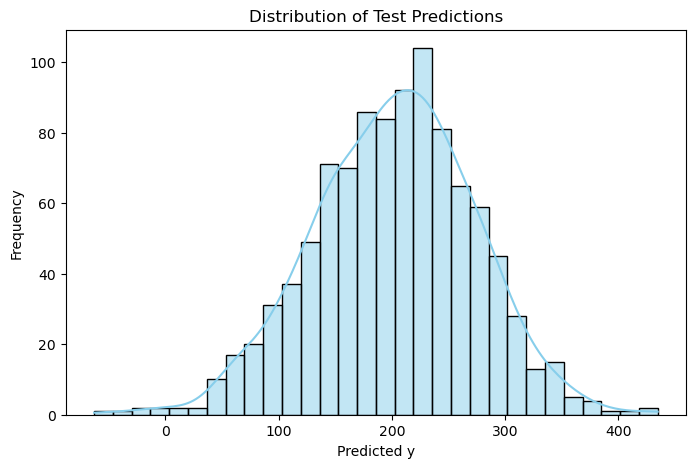

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(y_test_pred, bins=30, kde=True, color='skyblue')
plt.title("Distribution of Test Predictions")
plt.xlabel("Predicted y")
plt.ylabel("Frequency")
plt.savefig("Histogram of Test predictions.png")
plt.show()

In [188]:
import numpy as np

rmse_estimate = np.mean(outer_rmse_enet)

print(rmse_estimate)

30.368992532949626


In [189]:
import pandas as pd

rmse_df = pd.DataFrame([rmse_estimate], columns=["RMSE"])

rmse_df.to_csv("estimatedRMSE_s252629.csv", index=False)